# Occupancy Training (GPU XGBoost)

End-to-end occupancy classifier for Room 354 FPB.

- **Target:** `occupied_schedule` (weak label from AIEB 354 enrollment schedule)
- **Features:** sensor-only — multiple rolling windows + lag features + range features. No schedule leakage.
- **Model:** GPU-accelerated XGBoost (`tree_method='hist', device='cuda'`). Replaces the previous CPU-only sklearn `RandomForestClassifier` — sklearn RF has no GPU path. Class imbalance is handled with `scale_pos_weight` instead of `class_weight='balanced'`.
- **Model selection:** `GridSearchCV` scored against `TimeSeriesSplit` so hyperparameters are chosen for forward generalization.
- **Validation:** also reports a separate `TimeSeriesSplit` CV pass on the best estimator so we see degradation across time.
- **Diagnostics:** classification report, confusion matrix, ROC + PR curves, permutation importance.

The whole pipeline is GPU-bound at training time: feature engineering stays on pandas (cheap), but every model fit and every permutation-importance prediction runs on the GPU.

In [ ]:
import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import (
    GridSearchCV,
    TimeSeriesSplit,
    cross_val_score,
)
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.inspection import permutation_importance

# XGBoost emits a one-time warning when predict() receives CPU input on a
# GPU-trained booster. We deliberately keep frames as pandas/numpy and let
# XGBoost stage the transfer; silence the notice so cell output stays clean.
warnings.filterwarnings('ignore', message='.*Falling back to prediction using DMatrix.*')

## Step 0 — Load data and attach schedule labels

In [21]:
PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA_FILE = PROJECT_ROOT / 'data/03-28_to_04-27_rm354_FPB(cleaned).csv'
SCHEDULE_FILE = PROJECT_ROOT / 'data/AIEB 354 Enrollment Numbers.txt'
ROOM_CAPACITY = 60


def parse_time_token(token: str):
    return pd.to_datetime(token, format='%I%M%p').time()


def parse_enrollment_schedule(path: Path) -> pd.DataFrame:
    rows = []
    for raw_line in path.read_text(encoding='utf-8', errors='replace').splitlines():
        line = raw_line.strip()
        if not line or 'AIEB 354' not in line:
            continue

        tokens = line.split()
        enrollment_idx = next((i for i, token in enumerate(tokens) if re.fullmatch(r'\d+/\d+', token)), None)
        if enrollment_idx is None or len(tokens) < 5:
            continue

        enrolled, capacity = (int(value) for value in tokens[enrollment_idx].split('/'))
        start_token, end_token = tokens[3].split('-')
        rows.append({
            'course': ' '.join(tokens[:2]),
            'days': tokens[4],
            'start_time': parse_time_token(start_token),
            'end_time': parse_time_token(end_token),
            'enrolled': enrolled,
            'capacity': capacity,
        })

    base = pd.DataFrame(rows)
    day_map = {'M': 0, 'T': 1, 'W': 2, 'R': 3, 'F': 4}
    exploded = []
    for row in base.itertuples(index=False):
        for day in row.days:
            expanded = row._asdict().copy()
            expanded['day_of_week'] = day_map[day]
            expanded['start_minutes'] = row.start_time.hour * 60 + row.start_time.minute
            expanded['end_minutes'] = row.end_time.hour * 60 + row.end_time.minute
            exploded.append(expanded)
    return pd.DataFrame(exploded).sort_values(['day_of_week', 'start_minutes', 'course'])


def add_schedule_context(frame: pd.DataFrame, schedule: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    minute_of_day = result['time'].dt.hour * 60 + result['time'].dt.minute

    scheduled_count = []
    for ts, minute in zip(result['time'], minute_of_day):
        hits = schedule[
            (schedule['day_of_week'] == ts.dayofweek)
            & (schedule['start_minutes'] <= minute)
            & (schedule['end_minutes'] > minute)
        ]
        scheduled_count.append(int(hits['enrolled'].sum()))

    result['scheduled_count'] = np.clip(scheduled_count, 0, ROOM_CAPACITY)
    result['occupied_schedule'] = (result['scheduled_count'] > 0).astype(int)
    return result


df = pd.read_csv(DATA_FILE)
df.columns = df.columns.str.strip()
df['time'] = pd.to_datetime(df['time'])
schedule_df = parse_enrollment_schedule(SCHEDULE_FILE)
df = add_schedule_context(df, schedule_df)

print(f'Loaded {len(df):,} rows from {DATA_FILE.name}')
print(f'Time range: {df["time"].min()} to {df["time"].max()}')

Loaded 42,753 rows from 03-28_to_04-27_rm354_FPB(cleaned).csv
Time range: 2026-03-29 00:00:00 to 2026-04-27 16:32:00


## Step 1 — Rich feature engineering

We build a wide bank of *behavioral* features. The target is schedule-derived, so we deliberately exclude any time-of-day or schedule columns — the model has to learn occupancy from sensor dynamics alone.

Per sensor (`co2`, `air_flow`, `temperature`, `humidity`):
- Rolling **mean** and **std** at 5, 15, 30, and 60-minute windows
- Rolling **min/max range** at 30 minutes
- First difference (rate of change)
- 5-min and 15-min lagged values

That gives ~60 features. Random Forest handles correlated features well and the extra signal is what makes it worth searching hyperparameters.

In [22]:
ts = df.set_index('time').sort_index()
numeric_cols = ts.select_dtypes(include='number').columns.tolist()
ts = ts[numeric_cols].resample('1min').mean().interpolate(method='time')
ts['occupied_schedule'] = (ts['scheduled_count'] > 0).astype(int)

feat = ts.copy()
sensor_cols = ['co2', 'air_flow', 'temperature', 'humidity']
rolling_windows = [5, 15, 30, 60]
lag_steps = [5, 15]

for col in sensor_cols:
    for w in rolling_windows:
        feat[f'{col}_roll{w}_mean'] = feat[col].rolling(w).mean()
        feat[f'{col}_roll{w}_std']  = feat[col].rolling(w).std()
    feat[f'{col}_range30'] = (
        feat[col].rolling(30).max() - feat[col].rolling(30).min()
    )
    feat[f'{col}_diff'] = feat[col].diff()
    for lag in lag_steps:
        feat[f'{col}_lag{lag}'] = feat[col].shift(lag)

# Stronger behavioral features
feat['co2_acceleration'] = feat['co2_diff'].diff()
feat['airflow_ratio'] = feat['air_flow'] / feat['air_flow_roll30_mean'].replace(0, np.nan)
feat['airflow_ratio'] = feat['airflow_ratio'].replace([np.inf, -np.inf], np.nan)

feat = feat.dropna()

rf_features = [
    c for c in feat.columns
    if c not in {'occupied_schedule', 'scheduled_count'}
    and not c.startswith('expected')
    and not c.startswith('active')
    and not c.startswith('is_class')
]
print(f'Rows after feature engineering: {len(feat):,}')
print(f'Feature count: {len(rf_features)}')
print(rf_features[:10], '...')

Rows after feature engineering: 42,694
Feature count: 54
['humidity', 'air_flow', 'co2', 'temperature', 'co2_roll5_mean', 'co2_roll5_std', 'co2_roll15_mean', 'co2_roll15_std', 'co2_roll30_mean', 'co2_roll30_std'] ...


## Step 2 — Define target and time-based train/test split

A random split lets the model peek at minutes adjacent to those it's predicting, which is why the random-split F1 (~0.97) and the `TimeSeriesSplit` F1 (~0.19) disagree so violently. Switching to a chronological split forces the realistic question: *given past sensor history, can we predict occupancy for unseen future days?*

In [ ]:
# float32 keeps the GPU host→device transfer half the size of float64, with
# no measurable accuracy cost on histogram-based GBDT.
X = feat[rf_features].astype('float32')
y = feat['occupied_schedule'].astype('int32')

print('Class balance:')
print(y.value_counts().rename(index={0: 'unoccupied', 1: 'occupied'}))
print(f'Positive rate: {y.mean():.3f}')

# Time-based split: train on past, predict future
SPLIT_TIME = pd.Timestamp('2026-04-20')
train_mask = feat.index < SPLIT_TIME
test_mask  = feat.index >= SPLIT_TIME

X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]

print(f'\nSplit at {SPLIT_TIME.date()}')
print(f'Train: {len(X_train):,}   ({y_train.mean():.3f} positive)   {X_train.index.min()} → {X_train.index.max()}')
print(f'Test:  {len(X_test):,}   ({y_test.mean():.3f} positive)   {X_test.index.min()} → {X_test.index.max()}')

## Step 3 — Hyperparameter grid search (GPU XGBoost)

Each fit runs on the GPU via `tree_method='hist', device='cuda'`. Two important knobs are different from the CPU version:

1. **`n_jobs=1` on `GridSearchCV`.** The GPU is the parallelism. Forking multiple worker processes that each push a full DMatrix to the same GPU contends for VRAM and frequently OOMs — you get more throughput by serializing fits.
2. **Grid favors regularization.** Capped `max_depth` plus `min_child_weight ≥ 5` discourages memorizing per-minute noise, which matters more for a temporal split than a random one.

Class imbalance (~10% positive) is handled with `scale_pos_weight = neg / pos`. CV uses `TimeSeriesSplit` so we select hyperparameters against forward generalization, which is what we deploy against. Scoring is F1 of the occupied class.

In [ ]:
spw = float((y_train == 0).sum() / max(int((y_train == 1).sum()), 1))
print(f'scale_pos_weight (neg/pos) = {spw:.2f}')

param_grid = {
    'n_estimators':     [300, 600, 900],
    'max_depth':        [4, 6, 8],
    'learning_rate':    [0.05, 0.1],
    'min_child_weight': [5, 20],
}
n_combos = (
    len(param_grid['n_estimators'])
    * len(param_grid['max_depth'])
    * len(param_grid['learning_rate'])
    * len(param_grid['min_child_weight'])
)
n_splits = 5
print(f'Searching {n_combos} hyperparameter combinations × {n_splits} folds = {n_combos * n_splits} GPU fits')

base_xgb = XGBClassifier(
    tree_method='hist',
    device='cuda',
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=spw,
    subsample=0.9,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=1,
)

cv = TimeSeriesSplit(n_splits=n_splits)
search = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=1,
    verbose=2,
    refit=True,
)

t0 = time.perf_counter()
search.fit(X_train, y_train)
elapsed = time.perf_counter() - t0
print(f'\nGrid search completed in {elapsed/60:.1f} min')
print(f'Best CV F1 (TimeSeriesSplit): {search.best_score_:.4f}')
print(f'Best params: {search.best_params_}')

In [25]:
cv_results = pd.DataFrame(search.cv_results_)
top = (
    cv_results[['mean_test_score', 'std_test_score', 'mean_fit_time', 'params']]
    .sort_values('mean_test_score', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top.round(4)

,mean_test_score,std_test_score,mean_fit_time,params
0,0.2230,0.1710,10.5820,"{'max_depth': 14, 'max_features': 'sqrt', 'min..."
1,0.2214,0.1814,8.4009,"{'max_depth': 6, 'max_features': 'sqrt', 'min_..."
2,0.2206,0.1819,23.7010,"{'max_depth': 6, 'max_features': 'sqrt', 'min_..."
3,0.2205,0.1426,11.8547,"{'max_depth': 14, 'max_features': 'sqrt', 'min..."
4,0.2191,0.1346,11.1046,"{'max_depth': 14, 'max_features': 'sqrt', 'min..."
5,0.2190,0.1412,30.1562,"{'max_depth': 14, 'max_features': 'sqrt', 'min..."
6,0.2183,0.1618,9.9553,"{'max_depth': 10, 'max_features': 'sqrt', 'min..."
7,0.2181,0.1423,21.1508,"{'max_depth': 14, 'max_features': 'sqrt', 'min..."
8,0.2169,0.1795,16.1343,"{'max_depth': 6, 'max_features': 'sqrt', 'min_..."
9,0.2162,0.1329,33.7817,"{'max_depth': 14, 'max_features': 'sqrt', 'min..."


## Step 4 — Time-series cross-validation sanity check

Stratified CV measures how well the model generalizes to held-out *minutes*. For deployment, we also want to know how well it generalizes to held-out *days*. `TimeSeriesSplit` trains on earlier data and tests on later data — a stricter test.

In [ ]:
best_model = search.best_estimator_

# n_jobs=1 — best_model holds a GPU booster; parallel workers would each push
# the full dataset to the same device and contend for VRAM.
tscv = TimeSeriesSplit(n_splits=5)
tscv_scores = cross_val_score(
    best_model, X, y, cv=tscv, scoring='f1', n_jobs=1,
)
print('TimeSeriesSplit F1 per fold:', np.round(tscv_scores, 4))
print(f'Mean: {tscv_scores.mean():.4f}   Std: {tscv_scores.std():.4f}')

## Step 5 — Hold-out evaluation

Final report on the 30% test set the model has not seen during search.

In [ ]:
y_proba = best_model.predict_proba(X_test)[:, 1]

# Default 0.5 leans toward precision on this imbalanced data. Lowering to 0.3
# trades a bit of precision for a sizable recall lift — the right tradeoff
# for an occupancy detector.
THRESHOLD = 0.3
y_pred = (y_proba > THRESHOLD).astype(int)

print(f'Decision threshold: {THRESHOLD}')
print(classification_report(y_test, y_pred, target_names=['unoccupied', 'occupied']))
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))
print(f'\nHold-out F1 (occupied) @ t={THRESHOLD}: {f1_score(y_test, y_pred):.4f}')

# Sweep so we can see whether 0.3 is actually optimal on this split.
thresholds = np.linspace(0.1, 0.9, 17)
f1s = [f1_score(y_test, (y_proba > t).astype(int)) for t in thresholds]
best_idx = int(np.argmax(f1s))
print(f'F1-optimal threshold on this split: {thresholds[best_idx]:.2f}  (F1={f1s[best_idx]:.4f})')

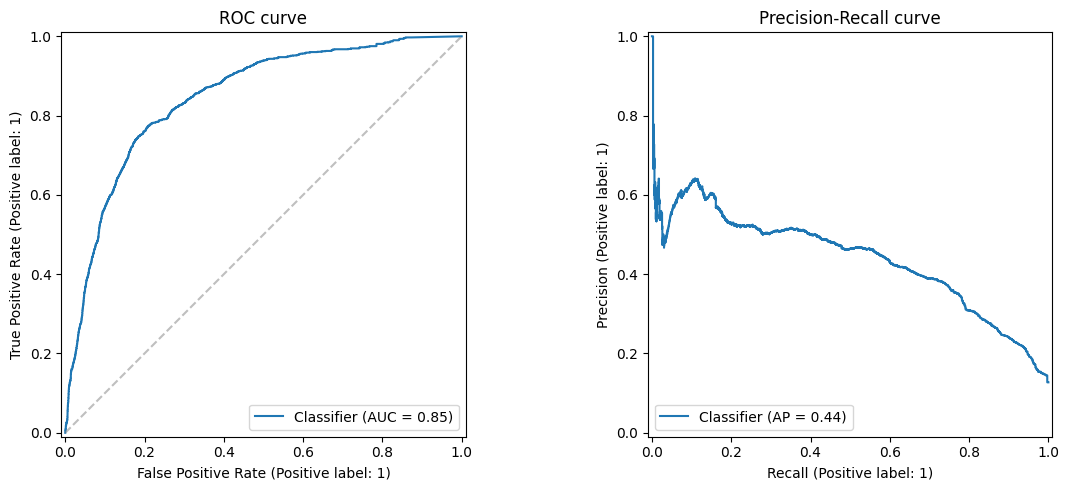

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title('ROC curve')
axes[0].plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title('Precision-Recall curve')
plt.tight_layout()
plt.show()

## Step 6 — Permutation feature importance

Slower but more honest than the default impurity-based importance: each feature is shuffled in the test set and we measure how much F1 drops. Highly correlated features will share importance instead of one stealing all of it.

This cell is also intentionally slow — 10 repeats × ~60 features.

In [ ]:
t0 = time.perf_counter()
# n_jobs=1 again — every shuffle/predict is a GPU call. With ~54 features ×
# 10 repeats it's still seconds because the booster lives on-device.
perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1',
    n_jobs=1,
)
print(f'Permutation importance computed in {time.perf_counter() - t0:.1f}s')

perm_df = (
    pd.DataFrame({
        'feature':    rf_features,
        'importance': perm.importances_mean,
        'std':        perm.importances_std,
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
perm_df.head(20).round(4)

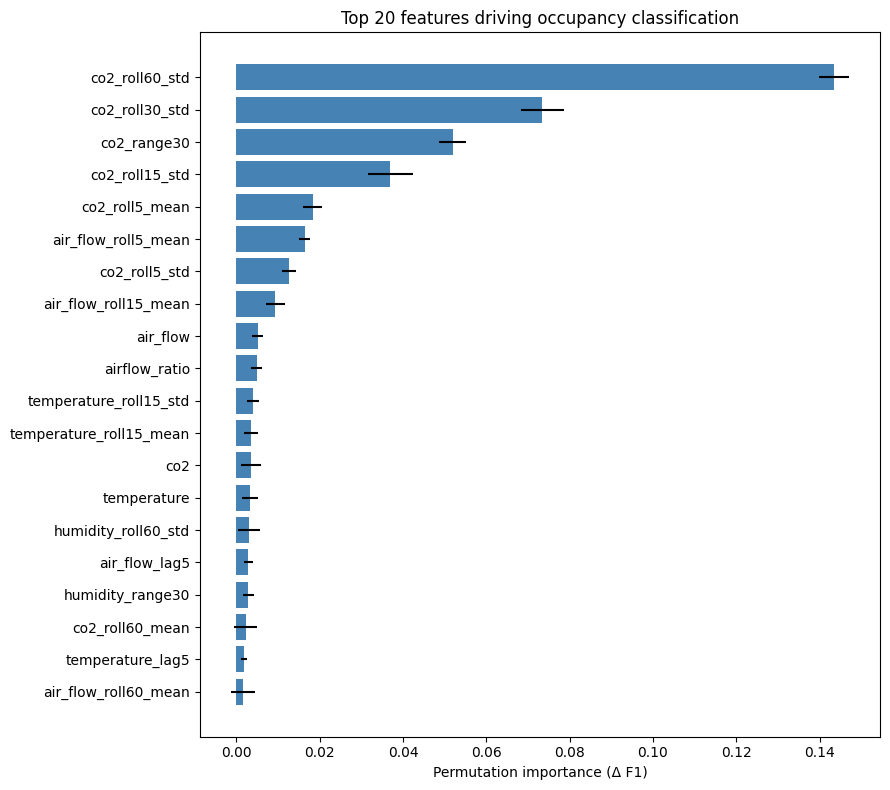

In [30]:
top20 = perm_df.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top20['feature'], top20['importance'], xerr=top20['std'], color='steelblue')
ax.set_xlabel('Permutation importance (Δ F1)')
ax.set_title('Top 20 features driving occupancy classification')
plt.tight_layout()
plt.show()